# 3D Reliability Field Viewer

Render the full 3D reliability field `R(x)` with transparent low values so zero-like regions do not appear as black blockers.


In [9]:
from pathlib import Path

NPY_PATH = Path(r"H:\AGPE-Inv_FINAL\AGPE-Inv_FINAL-main\results\projection_sweep_20260306_182338_954526\01_r51_nobw_rb100_cf060_ls23\VishalNet_cov_para_Facies_prj5_anchor_ws_tight_nobw_cache200_r51_rb100_cf060_ls23_s_uns_Stanford_VI_R3d_HILXL.npy")
REFERENCE_NPY = None
INPUT_MODE = "cube3d"  # cube3d for *_R3d_HILXL.npy or *_R3d_ILXLH.npy
CUBE_MAPPING = (1, 2, 0)  # H,IL,XL -> IL,XL,S ; if using *_R3d_ILXLH.npy set to (0,1,2)

DISPLAY_IN_INDEX_UNITS = True
X_TICK_STEP_IDX = 25
Y_TICK_STEP_IDX = 25
Z_TICK_STEP_IDX = 20

CMAP = "turbo"
VMIN = 0.0
VMAX = 1.0
ROBUST_CLIP = (0.5, 99.5)

# Volume rendering controls
VIS_THRESHOLD = 0.01       # values below this are treated as fully transparent
ALPHA_GAMMA = 0.60        # lower => stronger visibility for mid-range values
ALPHA_MAX = 0.92
MAX_RENDER_POINTS = 120000
STRIDE_IL = 1
STRIDE_XL = 1
STRIDE_S = 1
RANDOM_SEED = 2026
POINT_SIZE = 6.0

# Rendering quality / layout
FIGSIZE = (13, 9)
DPI = 320
ELEV = 28
AZIM = -58
ROLL = 0
Z_ASPECT_SCALE = 0.35

TITLE = "3D Reliability Field R(x)"
SHOW_COLORBAR = True
SHOW_BOX = True
OUTPUT_PNG = None



In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"


def load_cube_ilxls(npy_path, input_mode="auto", reference_npy=None, cube_mapping=(2, 1, 0)):
    arr = np.load(npy_path)
    mode = input_mode
    if mode == "auto":
        mode = "flat_pred" if arr.ndim == 2 else "cube3d"

    if mode == "cube3d":
        if arr.ndim != 3:
            raise ValueError(f"cube3d mode expects a 3D array, got {arr.shape}")
        cube = np.transpose(arr, cube_mapping).astype(np.float32, copy=False)
        meta = {
            "mode": "cube3d",
            "input_shape": tuple(arr.shape),
            "cube_shape": tuple(cube.shape),
            "reference_npy": None,
        }
        return cube, meta

    if mode != "flat_pred":
        raise ValueError(f"unsupported input mode: {mode}")

    if arr.ndim != 2:
        raise ValueError(f"flat_pred mode expects a 2D array, got {arr.shape}")
    if reference_npy is None:
        raise ValueError("flat_pred mode requires REFERENCE_NPY")

    ref = np.load(reference_npy, mmap_mode="r")
    if ref.ndim != 3:
        raise ValueError(f"reference cube must be 3D, got {ref.shape}")

    h, il, xl = ref.shape
    expected_traces = il * xl
    if arr.shape == (expected_traces, h):
        cube = arr.reshape(il, xl, h)
    elif arr.shape == (h, expected_traces):
        cube = arr.T.reshape(il, xl, h)
    else:
        raise ValueError(
            f"cannot restore flat prediction {arr.shape}; expected ({expected_traces}, {h}) or ({h}, {expected_traces})"
        )

    cube = cube.astype(np.float32, copy=False)
    meta = {
        "mode": "flat_pred",
        "input_shape": tuple(arr.shape),
        "cube_shape": tuple(cube.shape),
        "reference_npy": str(reference_npy),
    }
    return cube, meta


def resolve_color_limits(cube, vmin=None, vmax=None, robust_clip=(1.0, 99.0)):
    if vmin is None:
        vmin = float(np.percentile(cube, robust_clip[0]))
    if vmax is None:
        vmax = float(np.percentile(cube, robust_clip[1]))
    if vmax <= vmin:
        vmax = vmin + 1e-6
    return float(vmin), float(vmax)


def make_index_ticks(count, step):
    ticks = np.arange(0, count, max(1, int(step)))
    if ticks[-1] != count - 1:
        ticks = np.unique(np.append(ticks, count - 1))
    labels = [str(int(v)) for v in ticks]
    return ticks.astype(float), labels


def _style_3d_axes(ax):
    ax.grid(False)
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        try:
            axis.pane.fill = False
            axis.pane.set_edgecolor((0, 0, 0, 0))
        except Exception:
            pass


def draw_bbox(ax, xlim, ylim, zlim, color="black", lw=1.0, alpha=0.6):
    x0, x1 = xlim
    y0, y1 = ylim
    z0, z1 = zlim
    edges = [
        ((x0, y0, z0), (x1, y0, z0)), ((x0, y1, z0), (x1, y1, z0)),
        ((x0, y0, z1), (x1, y0, z1)), ((x0, y1, z1), (x1, y1, z1)),
        ((x0, y0, z0), (x0, y1, z0)), ((x1, y0, z0), (x1, y1, z0)),
        ((x0, y0, z1), (x0, y1, z1)), ((x1, y0, z1), (x1, y1, z1)),
        ((x0, y0, z0), (x0, y0, z1)), ((x1, y0, z0), (x1, y0, z1)),
        ((x0, y1, z0), (x0, y1, z1)), ((x1, y1, z0), (x1, y1, z1)),
    ]
    for p0, p1 in edges:
        ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]], color=color, lw=lw, alpha=alpha)


def make_transparent_cmap(cmap_name="turbo"):
    base = cm.get_cmap(cmap_name, 256)
    arr = base(np.linspace(0, 1, 256))
    arr[0, -1] = 0.0
    return ListedColormap(arr)


def sample_volume_points(cube, vis_threshold=0.02, max_points=120000, stride_il=1, stride_xl=1, stride_s=1, random_seed=2026):
    sub = cube[::max(1, int(stride_il)), ::max(1, int(stride_xl)), ::max(1, int(stride_s))]
    mask = sub >= float(vis_threshold)
    coords = np.argwhere(mask)
    if coords.size == 0:
        return np.empty((0, 3), dtype=float), np.empty((0,), dtype=np.float32), sub.shape

    values = sub[mask].astype(np.float32, copy=False)
    if len(values) > int(max_points):
        rng = np.random.default_rng(int(random_seed))
        keep = rng.choice(len(values), size=int(max_points), replace=False)
        coords = coords[keep]
        values = values[keep]

    return coords.astype(np.float32), values, sub.shape


def values_to_facecolors(values, cmap_obj, norm, vis_threshold=0.02, alpha_gamma=0.75, alpha_max=0.92):
    colors_rgba = cmap_obj(norm(values))
    denom = max(1e-6, float(norm.vmax) - float(vis_threshold))
    scaled = np.clip((values - float(vis_threshold)) / denom, 0.0, 1.0)
    alpha = np.power(scaled, float(alpha_gamma)) * float(alpha_max)
    colors_rgba[:, -1] = alpha
    return colors_rgba


def plot_reliability_volume(
    cube,
    cmap="turbo",
    vmin=None,
    vmax=None,
    robust_clip=(0.5, 99.5),
    figsize=(12, 9),
    dpi=260,
    elev=28,
    azim=-58,
    roll=0,
    title="3D Reliability Field R(x)",
    show_colorbar=True,
    show_box=True,
    display_in_index_units=True,
    x_tick_step_idx=25,
    y_tick_step_idx=25,
    z_tick_step_idx=20,
    vis_threshold=0.02,
    alpha_gamma=0.75,
    alpha_max=0.92,
    max_render_points=120000,
    stride_il=1,
    stride_xl=1,
    stride_s=1,
    random_seed=2026,
    point_size=5.0,
    vertical_aspect_scale=0.35,
    output_png=None,
):
    il_n, xl_n, s_n = cube.shape
    xlim = (0.0, float(xl_n - 1))
    ylim = (0.0, float(il_n - 1))
    zlim = (0.0, float(s_n - 1))
    box_aspect = (xl_n, il_n, max(1.0, s_n * float(vertical_aspect_scale)))

    vmin, vmax = resolve_color_limits(cube, vmin=vmin, vmax=vmax, robust_clip=robust_clip)
    cmap_obj = make_transparent_cmap(cmap)
    norm = colors.Normalize(vmin=vmin, vmax=vmax)

    coords, values, sub_shape = sample_volume_points(
        cube,
        vis_threshold=vis_threshold,
        max_points=max_render_points,
        stride_il=stride_il,
        stride_xl=stride_xl,
        stride_s=stride_s,
        random_seed=random_seed,
    )

    fig = plt.figure(figsize=figsize, dpi=dpi)
    ax = fig.add_subplot(111, projection="3d")
    _style_3d_axes(ax)
    ax.set_proj_type("persp", focal_length=0.95)
    ax.set_position([0.03, 0.05, 0.94, 0.80])

    if len(values) > 0:
        xs = coords[:, 1]
        ys = coords[:, 0]
        zs = coords[:, 2]
        facecolors = values_to_facecolors(values, cmap_obj, norm, vis_threshold=vis_threshold, alpha_gamma=alpha_gamma, alpha_max=alpha_max)
        ax.scatter(xs, ys, zs, c=facecolors, s=float(point_size), marker='s', depthshade=False, linewidths=0)

    if show_box:
        draw_bbox(ax, xlim, ylim, zlim, color="black", lw=0.9, alpha=0.55)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_zlim(zlim[1], zlim[0])
    ax.set_box_aspect(box_aspect)
    ax.view_init(elev=elev, azim=azim, roll=roll)

    ax.set_xlabel("XL / X", labelpad=10)
    ax.set_ylabel("IL / Y", labelpad=10)
    ax.set_zlabel("S / Depth", labelpad=8)
    fig.suptitle(f"{title} | threshold={vis_threshold:.3f}, points={len(values)}", y=0.865, fontsize=18)

    xticks, xlabels = make_index_ticks(xl_n, x_tick_step_idx)
    yticks, ylabels = make_index_ticks(il_n, y_tick_step_idx)
    zticks, zlabels = make_index_ticks(s_n, z_tick_step_idx)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels)
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels)
    ax.set_zticks(zticks)
    ax.set_zticklabels(zlabels)

    if show_colorbar:
        mappable = cm.ScalarMappable(norm=norm, cmap=cmap_obj)
        mappable.set_array([])
        cax = fig.add_axes([0.07, 0.925, 0.86, 0.03])
        cb = fig.colorbar(mappable, cax=cax, orientation="horizontal")
        cb.set_label("Reliability R(x)")

    if output_png is not None:
        output_png = Path(output_png)
        output_png.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_png, bbox_inches="tight")

    plt.show()
    return fig, ax



In [11]:
cube, meta = load_cube_ilxls(
    NPY_PATH,
    input_mode=INPUT_MODE,
    reference_npy=REFERENCE_NPY,
    cube_mapping=CUBE_MAPPING,
)

print(meta)
print("R cube shape (IL, XL, S):", cube.shape)
print("R min/max:", float(cube.min()), float(cube.max()))
print("nonzero ratio:", float((cube > 0).mean()))



{'mode': 'cube3d', 'input_shape': (200, 200, 150), 'cube_shape': (200, 150, 200), 'reference_npy': None}
R cube shape (IL, XL, S): (200, 150, 200)
R min/max: 0.0 0.8435956239700317
nonzero ratio: 0.5775233333333334


C:\Users\Windows\AppData\Local\Temp\ipykernel_37400\685966593.py:108: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = cm.get_cmap(cmap_name, 256)


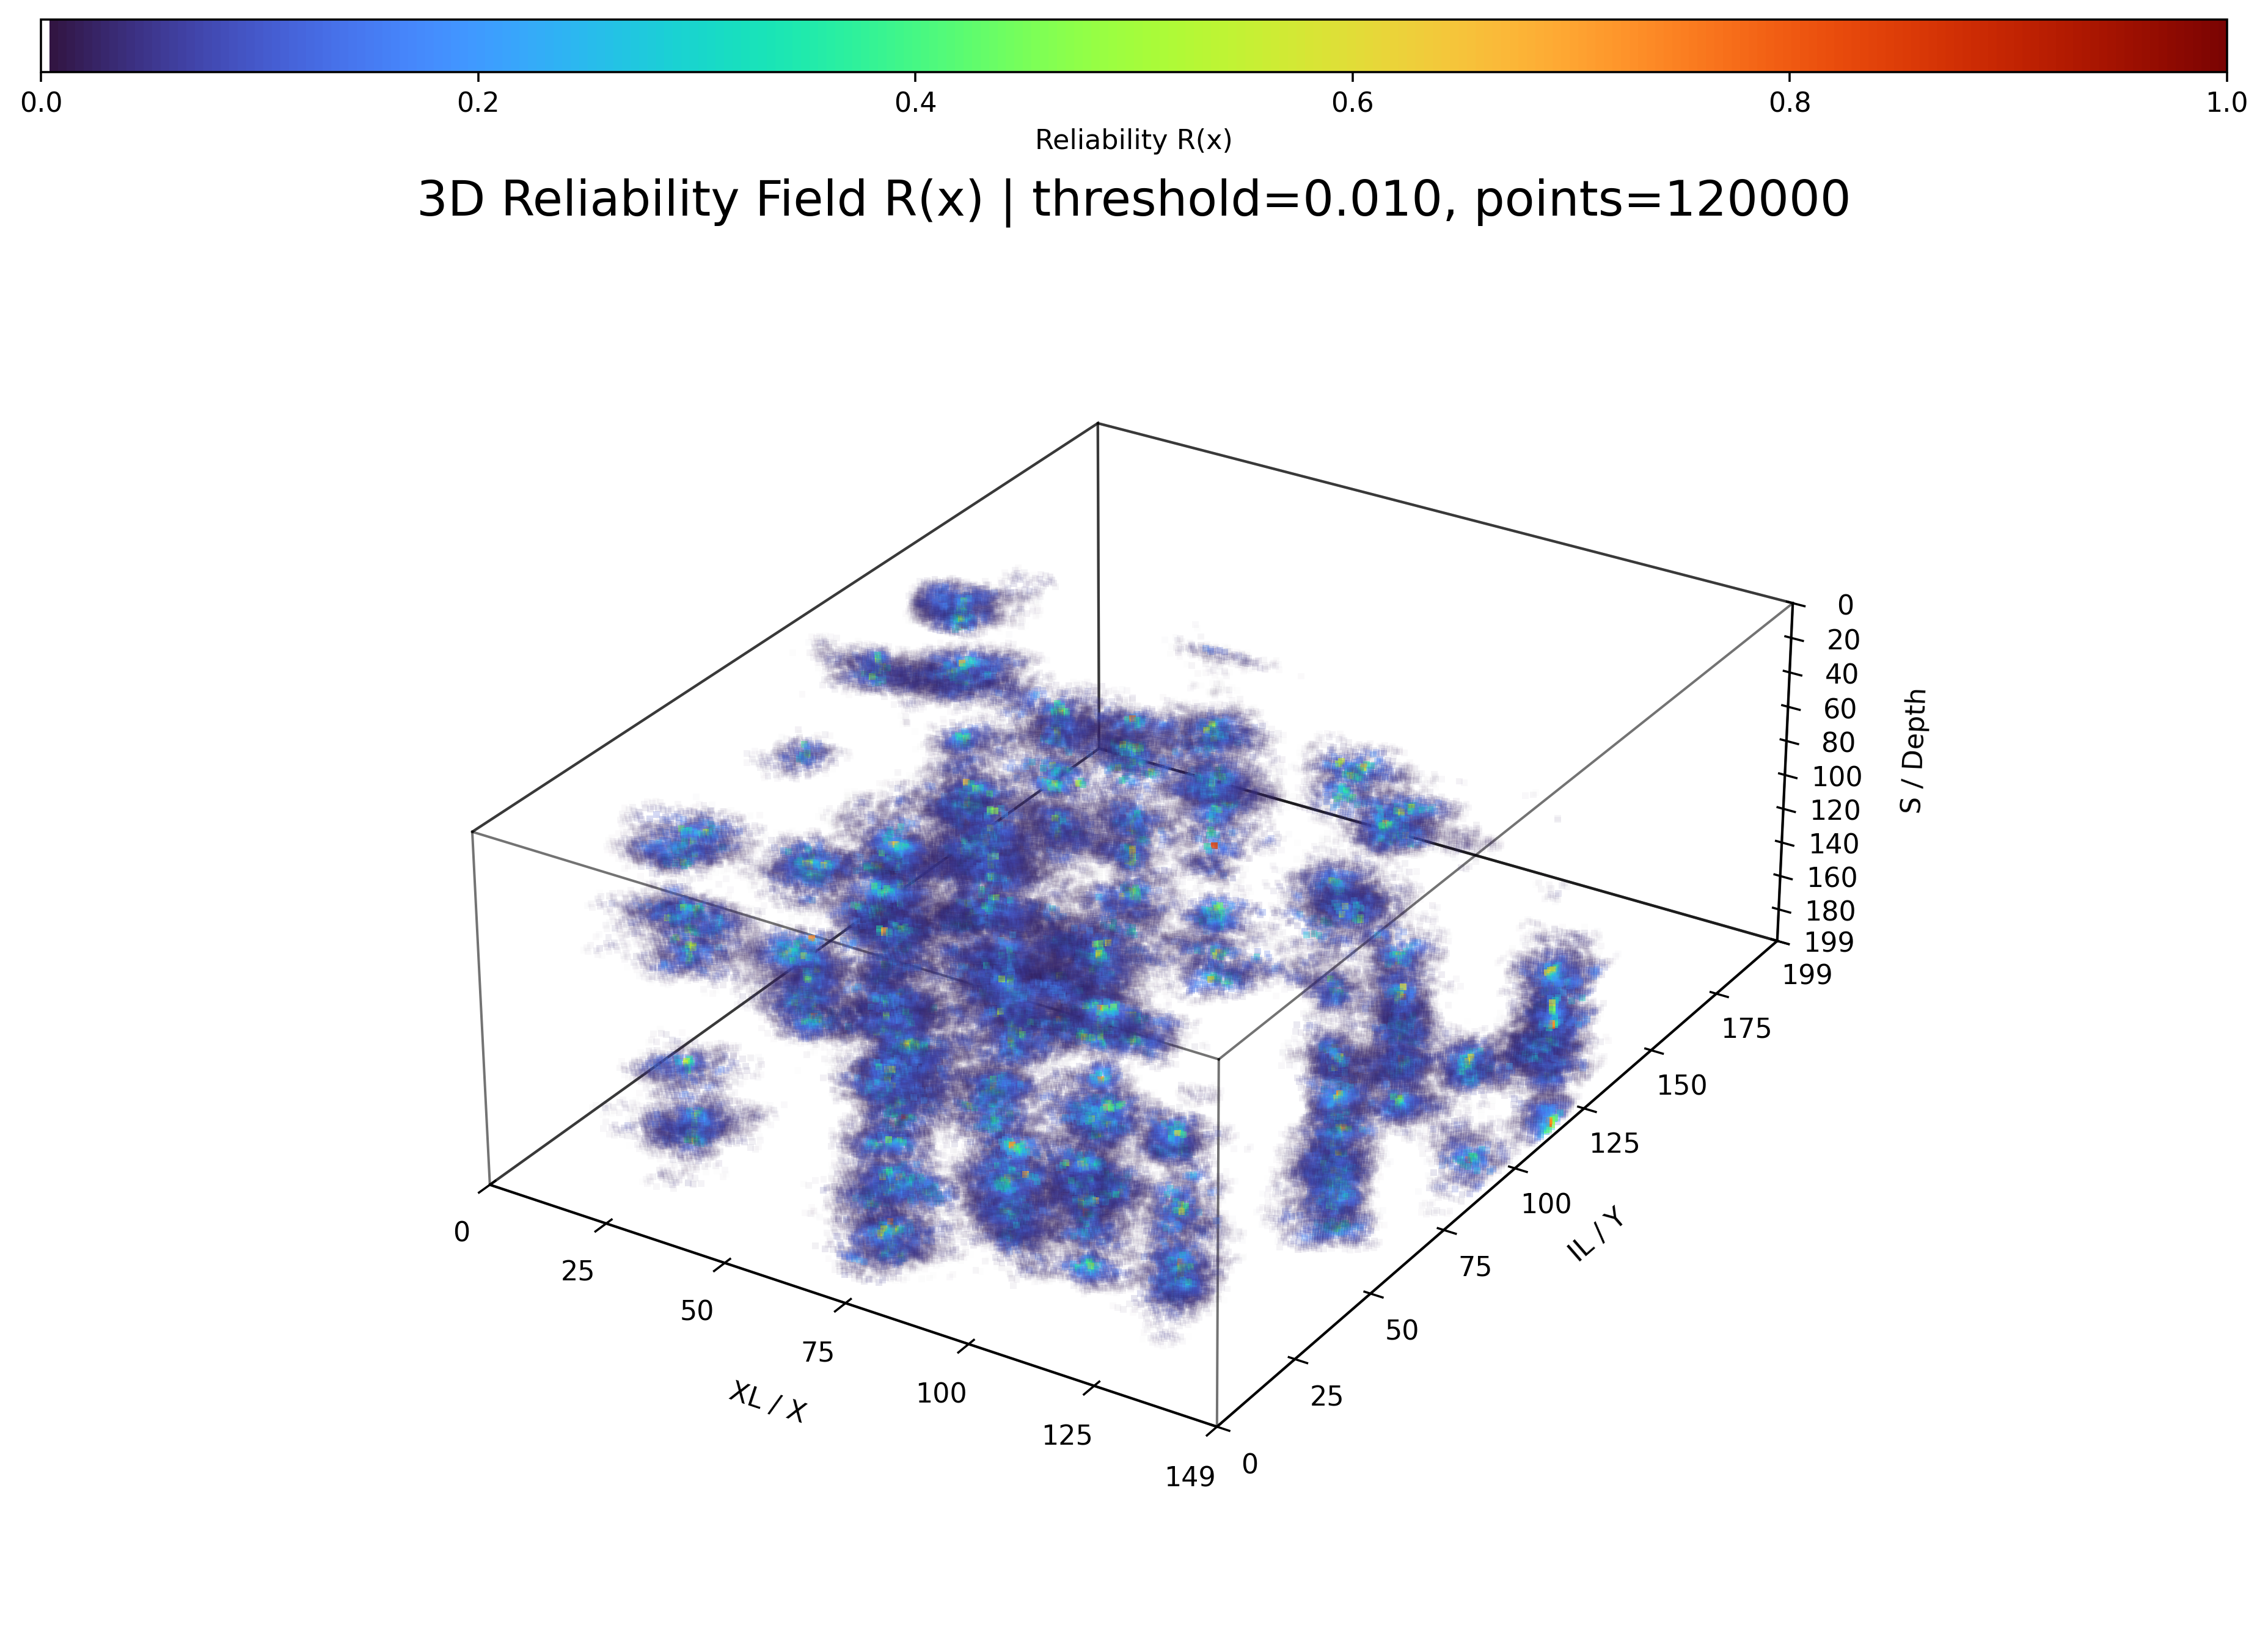

In [12]:
fig, ax = plot_reliability_volume(
    cube,
    cmap=CMAP,
    vmin=VMIN,
    vmax=VMAX,
    robust_clip=ROBUST_CLIP,
    figsize=FIGSIZE,
    dpi=DPI,
    elev=ELEV,
    azim=AZIM,
    roll=ROLL,
    title=TITLE,
    show_colorbar=SHOW_COLORBAR,
    show_box=SHOW_BOX,
    display_in_index_units=DISPLAY_IN_INDEX_UNITS,
    x_tick_step_idx=X_TICK_STEP_IDX,
    y_tick_step_idx=Y_TICK_STEP_IDX,
    z_tick_step_idx=Z_TICK_STEP_IDX,
    vis_threshold=VIS_THRESHOLD,
    alpha_gamma=ALPHA_GAMMA,
    alpha_max=ALPHA_MAX,
    max_render_points=MAX_RENDER_POINTS,
    stride_il=STRIDE_IL,
    stride_xl=STRIDE_XL,
    stride_s=STRIDE_S,
    random_seed=RANDOM_SEED,
    point_size=POINT_SIZE,
    vertical_aspect_scale=Z_ASPECT_SCALE,
    output_png=OUTPUT_PNG,
)

